In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv(r'E:\Projects in python\DEPI\FAS\datasets\raw\dataset 4\global_inflation_data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 47 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country_name    196 non-null    object 
 1   indicator_name  196 non-null    object 
 2   1980            140 non-null    float64
 3   1981            144 non-null    float64
 4   1982            145 non-null    float64
 5   1983            145 non-null    float64
 6   1984            145 non-null    float64
 7   1985            145 non-null    float64
 8   1986            145 non-null    float64
 9   1987            147 non-null    float64
 10  1988            147 non-null    float64
 11  1989            147 non-null    float64
 12  1990            150 non-null    float64
 13  1991            155 non-null    float64
 14  1992            158 non-null    float64
 15  1993            169 non-null    float64
 16  1994            171 non-null    float64
 17  1995            172 non-null    flo

In [4]:
df['country_name'] = df['country_name'].str.strip()

In [5]:
df =df.drop_duplicates()

In [6]:
print(f"Missing Values: {df.isnull().sum().sum()}")

Missing Values: 868


In [7]:
print(f"Duplicate Rows: {df.duplicated().sum()}")

Duplicate Rows: 0


In [8]:
year_cols = [col for col in df.columns if col.isdigit()]

In [9]:
df_long = df.melt(
    id_vars=['country_name', 'indicator_name'],
    value_vars=year_cols,
    var_name='year',
    value_name='inflation'
)

In [10]:
df_long['year'] = pd.to_numeric(df_long['year'])
df_long['inflation'] = pd.to_numeric(df_long['inflation'], errors='coerce')
df_long = df_long.dropna(subset=['inflation'])

In [11]:
primary_indicator = df_long['indicator_name'].unique()[0]
df_final = df_long[df_long['indicator_name'] == primary_indicator].copy()

In [12]:
global_stats = df_final.groupby('year')['inflation'].median().reset_index()

In [13]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='year', ylabel='inflation'>

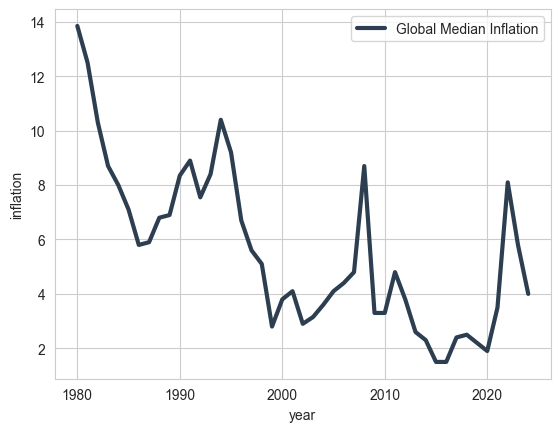

In [14]:
sns.lineplot(data=global_stats, x='year', y='inflation',
             color='#2c3e50', linewidth=3, label='Global Median Inflation')

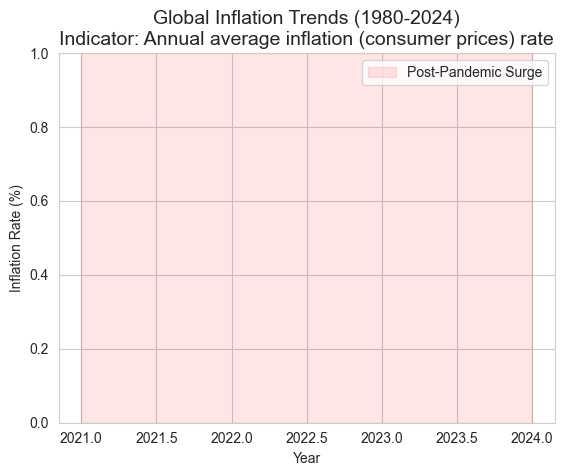

In [15]:
plt.axvspan(2021, 2024, color='red', alpha=0.1, label='Post-Pandemic Surge')

plt.title(f'Global Inflation Trends (1980-2024)\nIndicator: {primary_indicator}', fontsize=14)
plt.ylabel('Inflation Rate (%)')
plt.xlabel('Year')
plt.legend()
plt.show()

In [16]:
file_name = 'cleaned_global_inflation.csv'
df_final.to_csv(file_name, index=False)
print(f"✅ Success! '{file_name}' has been created.")

✅ Success! 'cleaned_global_inflation.csv' has been created.


In [17]:
threshold = df_final['inflation'].quantile(0.99)
outliers = df_final[df_final['inflation'] > threshold]

print(f"Inflation threshold for top 1%: {threshold:.2f}%")
print("\nCountries/Years with extreme hyperinflation:")
print(outliers[['country_name', 'year', 'inflation']].sort_values(by='inflation', ascending=False).head(10))

Inflation threshold for top 1%: 331.51%

Countries/Years with extreme hyperinflation:
                 country_name  year  inflation
7638                Venezuela  2018    65374.1
2783  Congo, Dem. Rep. of the  1994    23773.1
7834                Venezuela  2019    19906.0
1497                Nicaragua  1987    13109.5
1001                  Bolivia  1985    11749.6
2096                     Peru  1990     7481.7
1889                Nicaragua  1989     7428.7
2751                  Armenia  1994     5273.4
1693                Nicaragua  1988     4775.2
2731                  Ukraine  1993     4734.9


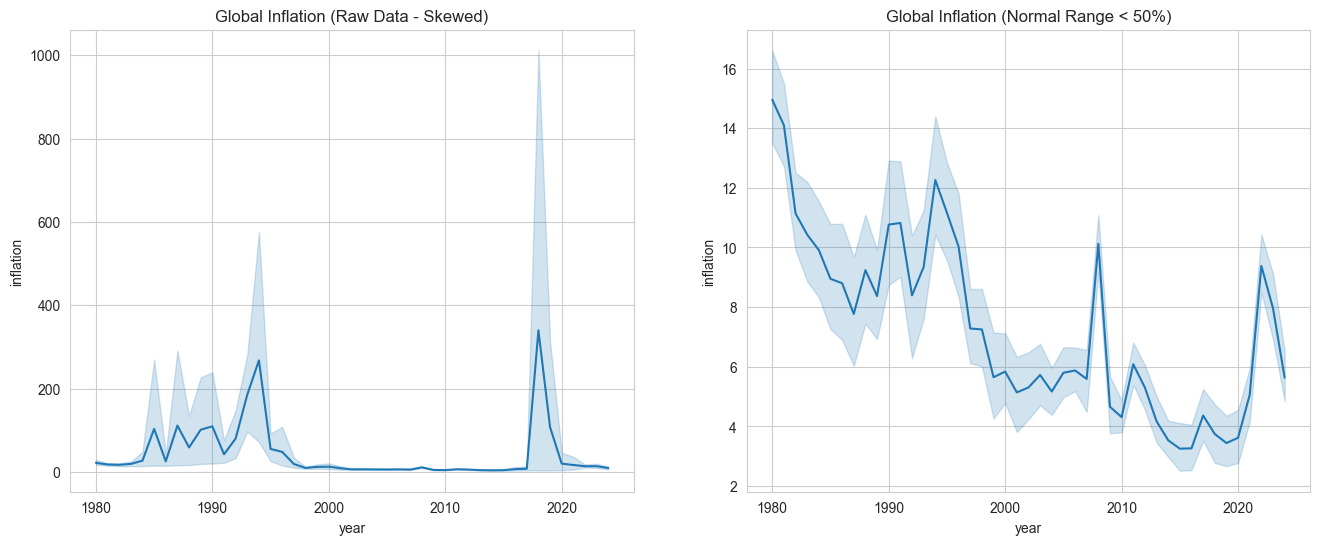

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

#  The Raw Data (With Outliers)
sns.lineplot(data=df_final, x='year', y='inflation', ax=ax[0])
ax[0].set_title("Global Inflation (Raw Data - Skewed)")

#  The 'Normal' Range (Filtered < 50%)
df_normal = df_final[df_final['inflation'] < 50]
sns.lineplot(data=df_normal, x='year', y='inflation', ax=ax[1])
ax[1].set_title("Global Inflation (Normal Range < 50%)")

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error

df = pd.read_csv(r'datasets/cleaned/dataset 4/training dataset.csv')
gt = df.groupby('year')['inflation'].median().reset_index()

gt['lag_1'] = gt['inflation'].shift(1)
gt['lag_2'] = gt['inflation'].shift(2)
gt['lag_3'] = gt['inflation'].shift(3)
gt['rolling_mean_3'] = gt['inflation'].shift(1).rolling(window=3).mean()
gt['rolling_std_3'] = gt['inflation'].shift(1).rolling(window=3).std()

df_ml = gt.dropna().copy()
features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3']
X, y = df_ml[features], df_ml['inflation']

# HYPERPARAMETER TUNING
param_grid = {
    'n_estimators': [10, 25, 50, 75, 100],
    'max_depth': [2, 3],
    'learning_rate': [0.01, 0.05, 0.1]
}

tscv = TimeSeriesSplit(n_splits=5)
grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X, y)

model = grid_search.best_estimator_

import os
import joblib

os.makedirs("trained_models", exist_ok=True)

y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print(f"--- Updated Metrics (Tuned GBM) ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"R2 Score: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f}%")

# ==========================
# Save Model
# ==========================

joblib.dump(
    model,
    "trained_models/inflation_model.pkl"
)

metadata = {

    "model_name": "GradientBoostingRegressor",

    "best_params": grid_search.best_params_,

    "features": features,

    "r2": r2,

    "mae": mae

}

joblib.dump(
    metadata,
    "trained_models/inflation_metadata.pkl"
)

print("Model Saved Successfully")

history = gt['inflation'].tolist()
forecast_results = []

for year in range(2025, 2035):
    X_in = pd.DataFrame([[
        history[-1],
        history[-2],
        history[-3],
        np.mean(history[-3:]),
        np.std(history[-3:])
    ]], columns=features)

    pred = model.predict(X_in)[0]

    history.append(pred)
    forecast_results.append({'year': year, 'inflation': pred})

forecast_df = pd.DataFrame(forecast_results)

plt.figure(figsize=(12, 6))
plt.plot(gt['year'], gt['inflation'], label='Historical Median', marker='o', color='#34495e')
plt.plot(forecast_df['year'], forecast_df['inflation'], label='Tuned GBM Forecast',
         marker='s', color='#e67e22', linestyle='--')

plt.title('Global Inflation: Tuned 10-Year Forecast (2025-2034)', fontsize=14)
plt.ylabel('Inflation Rate (%)')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("\n--- 10-Year Forecast Results ---")
print(forecast_df.to_string(index=False))